Dataset Shape: (569, 30)
Target Distribution:
target
1    357
0    212
Name: count, dtype: int64

Training Samples: 455
Testing Samples: 114

=== MODEL EVALUATION ===
Accuracy  : 0.9825
Precision : 0.9861
Recall    : 0.9861
F1 Score  : 0.9861
ROC-AUC   : 0.9954

=== CONFUSION MATRIX ===
[[41  1]
 [ 1 71]]


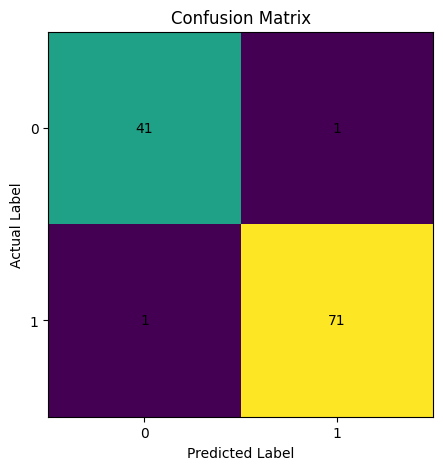


=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



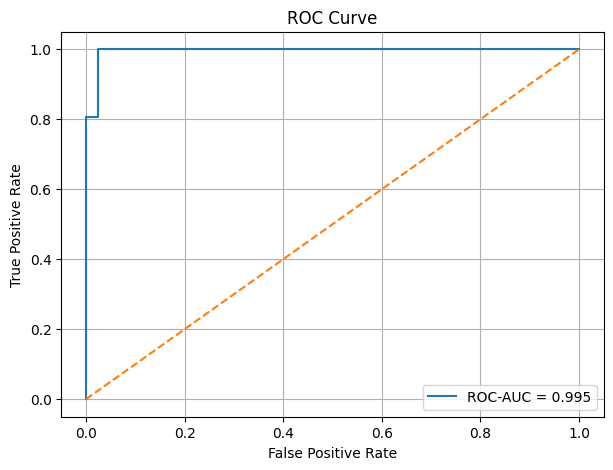


=== K-FOLD CROSS VALIDATION ===
Scores: [0.97368421 0.98245614 0.96491228 0.99122807 0.97345133]
Mean Accuracy: 0.9771
Std Deviation: 0.0090

=== STRATIFIED K-FOLD ===
Scores: [0.97368421 0.94736842 0.96491228 0.99122807 0.99115044]
Mean Accuracy: 0.9737
Std Deviation: 0.0166

=== CROSS-VALIDATION COMPARISON ===
                 Method  Accuracy
0      Train/Test Split  0.982456
1             K-Fold CV  0.977146
2  Stratified K-Fold CV  0.973669


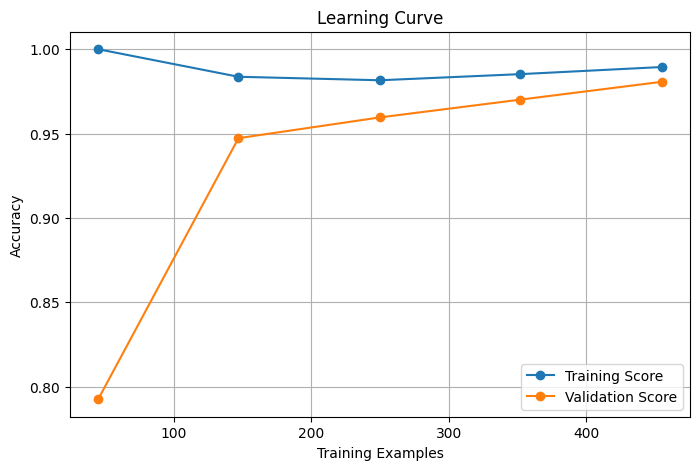


=== FINAL SUMMARY ===
Accuracy : 0.9825
Precision: 0.9861
Recall   : 0.9861
F1 Score : 0.9861
ROC-AUC  : 0.9954
K-Fold Mean Accuracy: 0.9771
Stratified K-Fold Mean Accuracy: 0.9737


In [1]:
# W4D1: Model Evaluation Metrics — Precision, Recall, AUC

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    KFold,
    StratifiedKFold,
    learning_curve
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

# ---------------------------------------------------------
# 1. Load Dataset
# ---------------------------------------------------------

data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

print("Dataset Shape:", X.shape)
print("Target Distribution:")
print(y.value_counts())

# ---------------------------------------------------------
# 2. Train/Test Split
# ---------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTraining Samples:", X_train.shape[0])
print("Testing Samples:", X_test.shape[0])

# ---------------------------------------------------------
# 3. Build Logistic Regression Pipeline
# ---------------------------------------------------------

model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(max_iter=1000))
])

# Train model
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# ---------------------------------------------------------
# 4. Calculate Evaluation Metrics
# ---------------------------------------------------------

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print("\n=== MODEL EVALUATION ===")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"ROC-AUC   : {auc:.4f}")

# ---------------------------------------------------------
# 5. Confusion Matrix
# ---------------------------------------------------------

cm = confusion_matrix(y_test, y_pred)

print("\n=== CONFUSION MATRIX ===")
print(cm)

plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xticks([0, 1])
plt.yticks([0, 1])
plt.show()

# ---------------------------------------------------------
# 6. Classification Report
# ---------------------------------------------------------

print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred))

# ---------------------------------------------------------
# 7. ROC Curve
# ---------------------------------------------------------

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"ROC-AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

# ---------------------------------------------------------
# 8. K-Fold Cross Validation
# ---------------------------------------------------------

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

kfold_scores = cross_val_score(
    model,
    X,
    y,
    cv=kf,
    scoring="accuracy"
)

print("\n=== K-FOLD CROSS VALIDATION ===")
print("Scores:", kfold_scores)
print(f"Mean Accuracy: {kfold_scores.mean():.4f}")
print(f"Std Deviation: {kfold_scores.std():.4f}")

# ---------------------------------------------------------
# 9. Stratified K-Fold Cross Validation
# ---------------------------------------------------------

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

stratified_scores = cross_val_score(
    model,
    X,
    y,
    cv=skf,
    scoring="accuracy"
)

print("\n=== STRATIFIED K-FOLD ===")
print("Scores:", stratified_scores)
print(f"Mean Accuracy: {stratified_scores.mean():.4f}")
print(f"Std Deviation: {stratified_scores.std():.4f}")

# ---------------------------------------------------------
# 10. Compare Cross-Validation Results
# ---------------------------------------------------------

results = pd.DataFrame({
    "Method": [
        "Train/Test Split",
        "K-Fold CV",
        "Stratified K-Fold CV"
    ],
    "Accuracy": [
        accuracy,
        kfold_scores.mean(),
        stratified_scores.mean()
    ]
})

print("\n=== CROSS-VALIDATION COMPARISON ===")
print(results)

# ---------------------------------------------------------
# 11. Learning Curve
# ---------------------------------------------------------

train_sizes, train_scores, validation_scores = learning_curve(
    model,
    X,
    y,
    cv=5,
    scoring="accuracy",
    train_sizes=np.linspace(0.1, 1.0, 5),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
validation_mean = validation_scores.mean(axis=1)

plt.figure(figsize=(8, 5))

plt.plot(
    train_sizes,
    train_mean,
    marker="o",
    label="Training Score"
)

plt.plot(
    train_sizes,
    validation_mean,
    marker="o",
    label="Validation Score"
)

plt.xlabel("Training Examples")
plt.ylabel("Accuracy")
plt.title("Learning Curve")
plt.legend()
plt.grid(True)
plt.show()

# ---------------------------------------------------------
# 12. Final Summary
# ---------------------------------------------------------

print("\n=== FINAL SUMMARY ===")
print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))
print("ROC-AUC  :", round(auc, 4))
print("K-Fold Mean Accuracy:", round(kfold_scores.mean(), 4))
print("Stratified K-Fold Mean Accuracy:",
      round(stratified_scores.mean(), 4))